# 노트북 00a — 왜 post-quantum cryptography인가?

오늘날의 암호는 충분히 큰 양자 컴퓨터가 등장하는 순간 무너집니다. 이 책은 그 대체 방식 중 하나인 **ML-KEM**과, 이를 처음부터 직접 구현하기 위해 필요한 것들을 다룹니다.

## 한 장으로 본 양자 위협

- **Shor 알고리즘** (1994): 충분히 큰 양자 컴퓨터에서 integer factorization과 discrete logarithm을 *다항 시간*에 풉니다. 이는 정확히 RSA, Diffie-Hellman, elliptic-curve crypto가 기반으로 하는 문제입니다. 따라서 Shor는 대규모로 실행될 경우 *현재의 거의 모든 공개키 암호*를 깨뜨립니다.
- **Grover 알고리즘**: 구조 없는 검색에 대한 quadratic speedup을 제공합니다. 대칭 암호를 약화시키지만(AES-128 → 약 64비트 양자 안전성) 깨뜨리지는 않습니다 — **키 크기를 두 배로 늘리는 것으로 충분합니다** (AES-256은 여전히 강력함).
- 핵심: **대칭 키와 해시 primitive는 대체로 괜찮습니다** (키 크기를 키우면 됨); **비대칭 암호는 전부 교체해야 합니다**.

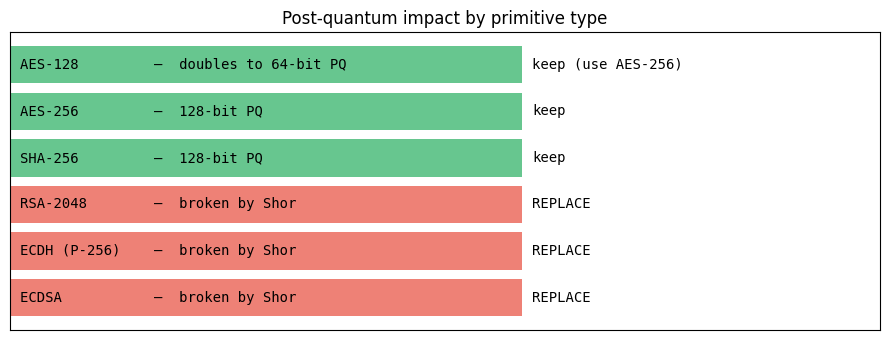

In [1]:
import matplotlib.pyplot as plt
primitives = [
    ("AES-128",      "symmetric",  "doubles to 64-bit PQ", "keep (use AES-256)"),
    ("AES-256",      "symmetric",  "128-bit PQ",           "keep"),
    ("SHA-256",      "hash",       "128-bit PQ",           "keep"),
    ("RSA-2048",     "asymmetric", "broken by Shor",       "REPLACE"),
    ("ECDH (P-256)", "asymmetric", "broken by Shor",       "REPLACE"),
    ("ECDSA",        "asymmetric", "broken by Shor",       "REPLACE"),
]
fig, ax = plt.subplots(figsize=(9, 3.5))
for i, (name, kind, q_impact, action) in enumerate(primitives):
    color = "#e74c3c" if "REPLACE" in action else "#27ae60"
    ax.barh(i, 1, color=color, alpha=0.7)
    ax.text(0.02, i, f"{name:14}  —  {q_impact}", va="center", fontsize=10, family="monospace")
    ax.text(1.02, i, action, va="center", fontsize=10, family="monospace")
ax.set_yticks([]); ax.set_xticks([]); ax.set_xlim(0, 1.7)
ax.set_title("Post-quantum impact by primitive type", fontsize=12)
ax.invert_yaxis()
plt.tight_layout(); plt.show()


## "지금 수집하고 나중에 해독한다 (Harvest now, decrypt later)"

공격자는 **오늘 암호화된 트래픽을 기록해 두고** (지금은 읽지 못하더라도) 양자 컴퓨터가 성숙하는 수 년 후에 해독할 수 있습니다. 기밀 유지 기간이 긴 데이터 — 정부 기밀, 의료 기록, 개인 대화, 지적재산 — 는 이미 위험에 노출되어 있습니다. PQC 마이그레이션이 Q-Day를 기다릴 수 없는 이유가 바로 이것입니다.

## 현재 우리는 어디에 있는가 (2024–2026)

- **2016**: NIST가 PQC 표준화 공모를 시작했습니다.
- **2022**: 네 개의 finalist 선정 (Kyber를 주요 KEM으로; signature에는 Dilithium, Falcon, SPHINCS+).
- **2024년 8월**: NIST가 **FIPS 203 (ML-KEM)**, **FIPS 204 (ML-DSA)**, **FIPS 205 (SLH-DSA)**를 공표했습니다.
- **2024년 이후**: Apple iMessage (PQ3), Signal (PQXDH), Chrome (X25519Kyber768), Cloudflare, AWS KMS 등 프로덕션 환경에 배포되었습니다.
- **Q-Day**: 아무도 모릅니다. 추정치는 "10년" 부터 "실용적 규모로는 영원히 없음" 까지 다양합니다. 그럼에도 마이그레이션은 *진행되고 있습니다* — harvest-now-decrypt-later 때문입니다.

## 이 책이 다루는 내용

우리는 **ML-KEM**을 구현합니다 — Diffie-Hellman 방식 키 교환에 대한 주요 post-quantum 대체 방안으로 NIST가 선정한 key encapsulation mechanism입니다. 이는 전체 그림의 한 조각입니다: digital signature (ML-DSA, SLH-DSA) 는 Part 3에서 간략히 다룹니다.

## 진행하기 전에

이미 RSA가 무엇을 하는지, KEM이 무엇인지 알고 있고 modular arithmetic에 익숙하다면 **Part 1을 건너뛰고** 바로 `01_lattice_intro`로 가세요. 그렇지 않다면 `00b_classical_crypto_recap`으로 이어서 진행하세요.